In [1]:
import os
import pickle as pkl
import numpy as np
import pandas as pd
from collections import Counter
cancer_list = ['KIRC', 'COAD', 'LAML', 'OV', 'BRCA', 'CESC', 'SKCM', 'LUAD', 'Glioma']

In [3]:
def get_common_data(sent_n=200):

    common_data_path = {
        'geneformer_emb_map': '/home/jienihu/sc/SLformer/data/saved_data/map/geneformer_emb.pkl', 
        'geneformer_emb_mtx': '/home/jienihu/sc/SLformer/data/saved_data/emb/geneformer_emb.npy', 
        "gene2sent_map": f"/home/jienihu/sc/SLformer/data/saved_data/map/gene2sent_n{sent_n}.pkl",
        "sent_mask_map": f"/home/jienihu/sc/SLformer/data/saved_data/map/sent_mask_n{sent_n}.pkl",
        "gene2id_map": "/home/jienihu/sc/SLformer/data/saved_data/map/gene2id.pkl",
    }
    
    # print(common_data_path)
    for data, path in common_data_path.items():
        if not os.path.exists(path):
            raise Exception(f"{data,path} cannot be found, please first construct it.")
    
    common_data = {}
    for data in ["geneformer_emb_map","gene2sent_map","sent_mask_map","gene2id_map"]:
        with open(common_data_path[data], 'rb') as f:
            common_data[data] = pkl.load(f)
    common_data["geneformer_emb_mtx"] = np.load(common_data_path["geneformer_emb_mtx"])
     
    cancer2id_map = {c:i for i,c in enumerate(cancer_list)}
    common_data["cancer_list"] = cancer_list
    common_data["cancer2id_map"] = cancer2id_map
    go_anno = pd.read_csv(os.path.join("/home/jienihu/sc/SLformer/data", "GO", "go_anno_popular.csv"))
    gene2go_map = dict(zip(go_anno["gene_id"], go_anno["GO_id"]))
    # gene2go_map = dict(zip(go_anno["gene_id"], go_anno["annotation"]))
    common_data["gene2go_map"] = gene2go_map
    
    # Load co-expression data
    common_data["cos_sim_kg"] = pd.read_csv("/home/guoyu/SLformer_interpretation/data/all_SL/cos_sim_kg_sorted.csv")
    common_data["func_cos_sim_kg"] = pd.read_csv("/home/guoyu/SLformer_interpretation/data/all_SL/func_cos_sim_kg.csv")
    
    return common_data

common_data = get_common_data()
common_data.keys()

dict_keys(['geneformer_emb_map', 'gene2sent_map', 'sent_mask_map', 'gene2id_map', 'geneformer_emb_mtx', 'cancer_list', 'cancer2id_map', 'gene2go_map', 'cos_sim_kg', 'func_cos_sim_kg'])

In [3]:
len(common_data['gene2sent_map'][0].keys()) # KIRC

8101

In [4]:
go_anno = pd.read_csv(os.path.join("/home/jienihu/sc/SLformer/data", "GO", "go_anno_popular.csv"))
go_anno['gene_id'].describe()

count    11898.000000
mean      6735.982938
std       3891.631531
min          0.000000
25%       3362.500000
50%       6748.500000
75%      10105.750000
max      13458.000000
Name: gene_id, dtype: float64

In [ ]:
def load_slformer_embeddings(embedding_type='cross', model_variant='kg', base_path="/home/guoyu/SLformer_interpretation/data/all_SL/"):
    """
    Load SLformer cross-attention or transformer embeddings.
    
    Parameters:
    -----------
    embedding_type : str
        Either 'cross' for cross-attention embeddings or 'transformer' for individual transformer embeddings
    model_variant : str  
        Either 'kg' (with knowledge graph) or 'nokg' (without knowledge graph)
    base_path : str
        Base path to the embedding files
        
    Returns:
    --------
    list: List of embedding arrays from different CV folds
    """
    
    if embedding_type == 'cross':
        filename = f"mix_slformer_{model_variant}_crossemb.pkl"
    elif embedding_type == 'transformer':
        filename = f"mix_slformer_{model_variant}_transformeremb.pkl"
    else:
        raise ValueError("embedding_type must be 'cross' or 'transformer'")
    
    filepath = os.path.join(base_path, filename)
    
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Embedding file not found: {filepath}")
    
    with open(filepath, 'rb') as f:
        embeddings = pkl.load(f)
    
    return embeddings

def analyze_embedding_similarity(embeddings, gene_pairs=None, embedding_type='cross'):
    """
    Analyze similarity patterns in the embeddings.
    
    Parameters:
    -----------
    embeddings : list
        Embeddings from load_slformer_embeddings()
    gene_pairs : list of tuples, optional
        Specific gene pairs to analyze
    embedding_type : str
        Type of embedding ('cross' or 'transformer')
        
    Returns:
    --------
    dict: Analysis results
    """
    
    results = {}
    
    # Analyze first fold as example
    if len(embeddings) > 0:
        first_fold = embeddings[0]
        
        if embedding_type == 'cross':
            # Cross embeddings have fusion outputs
            print("Cross-attention embedding analysis:")
            for i, emb_part in enumerate(first_fold):
                print(f"\nEmbedding part {i}: shape {emb_part.shape}")
                
                # Calculate some statistics
                mean_emb = np.mean(emb_part, axis=0)
                std_emb = np.std(emb_part, axis=0)
                
                print(f"  Mean embedding magnitude: {np.linalg.norm(mean_emb):.4f}")
                print(f"  Std of embedding magnitudes: {np.mean([np.linalg.norm(emb_part[j]) for j in range(min(100, emb_part.shape[0]))]):.4f}")
                
                results[f'part_{i}'] = {
                    'shape': emb_part.shape,
                    'mean_magnitude': np.linalg.norm(mean_emb),
                    'sample_magnitudes': [np.linalg.norm(emb_part[j]) for j in range(min(10, emb_part.shape[0]))]
                }
                
        else:
            # Transformer embeddings have individual gene representations
            print("Transformer embedding analysis:")
            for i, emb_part in enumerate(first_fold):
                print(f"\nGene {i+1} embeddings: shape {emb_part.shape}")
                
                # Calculate statistics for individual genes
                mean_emb = np.mean(emb_part, axis=0)
                print(f"  Mean embedding magnitude: {np.linalg.norm(mean_emb):.4f}")
                
                results[f'gene_{i+1}'] = {
                    'shape': emb_part.shape,
                    'mean_magnitude': np.linalg.norm(mean_emb)
                }
    
    return results

def get_embedding_for_gene_pair(embeddings, gene1, gene2, cancer, pred_df, common_data=None):
    """
    Extract embeddings for a specific gene pair and cancer type across all CV folds.
    
    Parameters:
    -----------
    embeddings : list
        List of embeddings from all CV folds
    gene1, gene2 : str
        Gene names to search for
    cancer : str
        Cancer type context (or None for all cancers)
    pred_df : DataFrame
        Combined prediction dataframe with gene pair information
    common_data : dict, optional
        Common data dictionary
        
    Returns:
    --------
    DataFrame with columns: gene1, gene2, context, SLscore, embedding_part_0, embedding_part_1, fold
    """
    
    results = []
    
    # Create mask for gene pair (both orientations)
    if cancer:
        mask = (((pred_df['primary_gene'] == gene1) & (pred_df['partner_gene'] == gene2)) |
                ((pred_df['primary_gene'] == gene2) & (pred_df['partner_gene'] == gene1))) & \
               (pred_df['cancer'] == cancer)
    else:
        mask = ((pred_df['primary_gene'] == gene1) & (pred_df['partner_gene'] == gene2)) | \
               ((pred_df['primary_gene'] == gene2) & (pred_df['partner_gene'] == gene1))
    
    matching_rows = pred_df[mask]
    
    if len(matching_rows) == 0:
        print(f"No matching gene pairs found for {gene1}-{gene2}" + (f" in {cancer}" if cancer else ""))
        return pd.DataFrame()
    
    print(f"Found {len(matching_rows)} matching instances for {gene1}-{gene2}" + (f" in {cancer}" if cancer else ""))
    
    # Group by CV fold (assuming we have 5 folds and indices are distributed accordingly)
    fold_size = len(pred_df) // len(embeddings) if len(embeddings) > 0 else len(pred_df)
    
    for _, row in matching_rows.iterrows():
        original_idx = row.name  # Original index in the combined dataframe
        fold_idx = original_idx // fold_size  # Determine which fold this belongs to
        fold_idx = min(fold_idx, len(embeddings) - 1)  # Ensure we don't exceed available folds
        local_idx = original_idx % fold_size  # Index within the fold
        
        if fold_idx < len(embeddings):
            fold_embeddings = embeddings[fold_idx]
            
            # Extract embeddings for this instance
            embedding_data = {}
            for i, emb_part in enumerate(fold_embeddings):
                if local_idx < emb_part.shape[0]:
                    embedding_data[f'embedding_part_{i}'] = emb_part[local_idx]
            
            # Create result record
            result_record = {
                'context': row['cancer'],
                'SLscore': row.get('score', row.get('label', None)),
                'fold': fold_idx,
                'primary_gene': row['primary_gene'],
                'partner_gene': row['partner_gene']
            }
            
            # Add embedding parts
            result_record.update(embedding_data)
            results.append(result_record)
           
    
    if results:
        result_df = pd.DataFrame(results)
        result_df = result_df.rename(columns=
                {'embedding_part_0': 'primary_embedding', 
                 'embedding_part_1': 'partner_embedding'})
        return result_df
    else:
        print(f"No embeddings extracted for {gene1}-{gene2}")
        return pd.DataFrame()

In [6]:
cross_emb_kg = load_slformer_embeddings(embedding_type='cross', model_variant='kg')
cross_emb_nokg = load_slformer_embeddings(embedding_type='cross', model_variant='nokg')
transformer_emb_kg = load_slformer_embeddings(embedding_type='transformer', model_variant='kg')
transformer_emb_nokg = load_slformer_embeddings(embedding_type='transformer', model_variant='nokg')

In [7]:
cross_analysis_kg = analyze_embedding_similarity(cross_emb_kg, embedding_type='cross')
cross_analysis_nokg = analyze_embedding_similarity(cross_emb_nokg, embedding_type='cross')

Cross-attention embedding analysis:

Embedding part 0: shape (11727, 512)
  Mean embedding magnitude: 3.6267
  Std of embedding magnitudes: 4.9870

Embedding part 1: shape (11727, 512)
  Mean embedding magnitude: 3.0090
  Std of embedding magnitudes: 3.5491
Cross-attention embedding analysis:

Embedding part 0: shape (11727, 256)
  Mean embedding magnitude: 2.7560
  Std of embedding magnitudes: 3.5231

Embedding part 1: shape (11727, 256)
  Mean embedding magnitude: 2.3265
  Std of embedding magnitudes: 2.5530


In [8]:
len(cross_emb_kg[2][0])

11727

In [ ]:
gene_preds = pd.DataFrame()
for i in range(5):
    path = f'/home/guoyu/SLformer_interpretation/data/all_SL/pred_mix_slformer_kg_cv{i+1}.csv'
    df = pd.read_csv(path)
    gene_preds = pd.concat([gene_preds, df], ignore_index=True)
gene_preds.shape

(58620, 4)

In [10]:
gene_preds[gene_preds['score'] > 0.5].shape

(1014, 4)

In [11]:
gene_pair = ['PARP1', 'BRCA1']
gene_pair_map = {
    'primary': 'BRCA1',
    'partner': 'PARP1'
}
context = None
# ===============================================================

# gene_pair = ['IDH1', 'PRKDC']
# gene_pair_map = {
#     'primary': 'IDH1',
#     'partner': 'PRKDC'
# }
# context = 'Glioma'
# score = idh1_glioma[0]

# ===============================================================

# gene_pair = ['PRMT5', 'MAT2A']
# gene_pair_map = {
#     'primary': 'MAT2A',
#     'partner': 'PRMT5'
# }
# context = 'Glioma'
# score = prmt5_glioma[0]

In [12]:
def search_pred(gene_pair, context=None):
    if context:
        df = gene_preds[((gene_preds['primary_gene'] == gene_pair[0]) & (gene_preds['partner_gene'] == gene_pair[1]) | (gene_preds['primary_gene'] == gene_pair[1]) & (gene_preds['partner_gene'] == gene_pair[0])) & (gene_preds['cancer'] == context)]
    else:
        df = gene_preds[((gene_preds['primary_gene'] == gene_pair[0]) & (gene_preds['partner_gene'] == gene_pair[1]) | (gene_preds['primary_gene'] == gene_pair[1]) & (gene_preds['partner_gene'] == gene_pair[0]))]
    
    return df if not context else df[0]
search_pred(gene_pair, context)

,primary_gene,partner_gene,cancer,score
17138,BRCA1,PARP1,COAD,0.002581
31884,BRCA1,PARP1,BRCA,0.985268
34301,BRCA1,PARP1,SKCM,0.922286
46994,BRCA1,PARP1,KIRC,0.295419
58495,BRCA1,PARP1,LUAD,0.008002


In [13]:
cross_emb_kg[0][1].shape

(11727, 512)

In [14]:
result_df_all_brca1 = get_embedding_for_gene_pair(
    embeddings=cross_emb_kg,
    gene1='PIK3CA',
    gene2='PTEN', 
    cancer=None,
    pred_df=gene_preds
)
result_df_all_brca1

Found 2 matching instances for PIK3CA-PTEN


,context,SLscore,fold,primary_gene,partner_gene,primary_embedding,partner_embedding
0,LUAD,0.003269,1,PIK3CA,PTEN,"[0.011429911, 0.034700092, 0.0, 0.0065607787, ...","[0.0, 0.0051890723, 0.010909398, 0.010648003, ..."
1,KIRC,0.000044,3,PIK3CA,PTEN,"[0.041282747, 0.21863012, 0.0, 0.01396149, 0.0...","[0.06567161, 0.13422734, 0.026026594, 0.067073..."


In [15]:
import numpy as np
import pandas as pd

def batch_extract_embeddings(embeddings, pred_df):
    """
    Efficiently extract embeddings for all gene pairs in all contexts.
    Returns a DataFrame with columns: primary_gene, partner_gene, context, SLscore, fold, primary_embedding, partner_embedding
    """
    results = []
    n_folds = len(embeddings)
    fold_sizes = [embeddings[i][0].shape[0] for i in range(n_folds)]
    pred_df = pred_df.reset_index(drop=True)
    # Assign fold and local_idx for each row
    fold_boundaries = np.cumsum([0] + fold_sizes)
    fold_idx_arr = np.zeros(len(pred_df), dtype=int)
    local_idx_arr = np.zeros(len(pred_df), dtype=int)
    for i in range(n_folds):
        start = fold_boundaries[i]
        end = fold_boundaries[i+1]
        fold_idx_arr[start:end] = i
        local_idx_arr[start:end] = np.arange(end - start)
    pred_df['fold'] = fold_idx_arr
    pred_df['local_idx'] = local_idx_arr

    # For each fold, extract all embeddings in batch
    for fold_idx in range(n_folds):
        fold_rows = pred_df[pred_df['fold'] == fold_idx]
        if fold_rows.empty:
            continue
        local_indices = fold_rows['local_idx'].values
        fold_embeddings = embeddings[fold_idx]
        # Only keep indices within the actual fold size
        valid_mask = local_indices < fold_embeddings[0].shape[0]
        fold_rows = fold_rows.iloc[valid_mask]
        local_indices = local_indices[valid_mask]
        if len(local_indices) == 0:
            continue
        primary_embs = fold_embeddings[0][local_indices]
        partner_embs = fold_embeddings[1][local_indices]
        fold_result = pd.DataFrame({
            'primary_gene': fold_rows['primary_gene'].values,
            'partner_gene': fold_rows['partner_gene'].values,
            'context': fold_rows['cancer'].values,
            'SLscore': fold_rows['score'].values if 'score' in fold_rows else fold_rows['label'].values,
            'fold': fold_idx,
            'primary_embedding': list(primary_embs),
            'partner_embedding': list(partner_embs)
        })
        results.append(fold_result)
    result_df_all = pd.concat(results, ignore_index=True)
    return result_df_all

# Usage:
result_df_all = batch_extract_embeddings(cross_emb_kg, gene_preds)
print(f"Shape: {result_df_all.shape}")
print(f"Unique contexts: {result_df_all['context'].unique()}")

Shape: (58620, 7)
Unique contexts: ['KIRC' 'COAD' 'LAML' 'OV' 'BRCA' 'CESC' 'SKCM' 'LUAD']


In [16]:
result_df_all.head()

,primary_gene,partner_gene,context,SLscore,fold,primary_embedding,partner_embedding
0,AKT1,BCL2,KIRC,0.000425,0,"[0.0, 0.097381, 0.3594243, 0.090319894, 0.7772...","[0.0, 0.0, 0.5528198, 0.113020614, 0.6490258, ..."
1,PTEN,RUNX1,KIRC,0.001516,0,"[0.03827591, 0.2651308, 0.6721244, 0.55382895,...","[0.0, 0.4048244, 0.3676368, 0.5108704, 0.70790..."
2,HDAC6,SMARCA4,KIRC,0.005020,0,"[0.0, 0.4122174, 0.21149161, 0.33804354, 0.648...","[0.0, 0.33933777, 0.5542548, 0.16128483, 0.727..."
3,ARID1A,PIK3R1,KIRC,0.000929,0,"[0.082625754, 0.20849644, 0.3810383, 0.3129659...","[0.033489056, 0.19248515, 0.0457877, 0.1894401..."
4,BRCA1,HDAC1,KIRC,0.015028,0,"[0.0008739635, 0.4577036, 0.50963384, 0.275150...","[0.0, 0.2276794, 0.5435709, 0.39347345, 0.4489..."


In [17]:
extraction_genes = list(result_df_all[['primary_gene', 'partner_gene', 'context', 'SLscore']].itertuples(index=False, name=None))
len(extraction_genes)

58620

In [18]:
geneformer_emb = common_data['geneformer_emb_map']
gene2id_map = common_data['gene2id_map']
id2cancer_map = {v: k for k, v in common_data['cancer2id_map'].items()}
geneformer_pairs = []
gene_list = list(gene2id_map.keys())
for (gene1, gene2, cancer, score) in extraction_genes:
    cancer_idx = common_data['cancer2id_map'].get(cancer, None)
    try:
        g1_idx = gene2id_map[gene1]
        g2_idx = gene2id_map[gene2]
        emb1 = geneformer_emb[cancer_idx][g1_idx]
        emb2 = geneformer_emb[cancer_idx][g2_idx]
        geneformer_pairs.append({
            'primary_gene': gene1,
            'partner_gene': gene2,
            'context': cancer,
            'primary_embedding': emb1,
            'partner_embedding': emb2,
            'SLscore': score
        })
    except Exception:
        continue  # skip missing genes
# Convert to DataFrame
geneformer_emb_df = pd.DataFrame(geneformer_pairs)
print(f"Geneformer embedding pairs shape: {geneformer_emb_df.shape}")
geneformer_emb_df.head()

Geneformer embedding pairs shape: (58620, 6)


,primary_gene,partner_gene,context,primary_embedding,partner_embedding,SLscore
0,AKT1,BCL2,KIRC,"[-0.008143925, 0.3002113, -0.46870166, -0.5202...","[-0.21746431, -0.070143744, -0.019538235, -0.0...",0.000425
1,PTEN,RUNX1,KIRC,"[-0.20849892, -0.018020904, 0.21425855, -0.111...","[-0.064044535, 0.051006738, -0.2696501, -0.105...",0.001516
2,HDAC6,SMARCA4,KIRC,"[-0.16344877, 0.32727766, -0.004315011, 0.2964...","[-0.11961124, 0.21211952, -0.11839655, 0.03133...",0.005020
3,ARID1A,PIK3R1,KIRC,"[-0.13765506, 0.22262987, -0.098285474, 0.3095...","[-0.14195183, -0.001685584, 0.10516551, -0.173...",0.000929
4,BRCA1,HDAC1,KIRC,"[-0.08558462, 0.09238001, -0.5329756, -0.23088...","[0.0784193, -0.21026465, -0.113381185, -0.2504...",0.015028


In [19]:
result_kg_emb_primary = pd.DataFrame(result_df_all['primary_embedding'].tolist())
result_kg_emb_primary.columns = [f'primary_emb_{i}' for i in range(result_kg_emb_primary.shape[1])]
result_kg_emb_partner = pd.DataFrame(result_df_all['partner_embedding'].tolist())
result_kg_emb_partner.columns = [f'partner_emb_{i}' for i in range(result_kg_emb_partner.shape[1])]
result_kg_emb_total = pd.concat([result_kg_emb_primary, result_kg_emb_partner], axis=1)
context_target = result_df_all['context']
sl_target = result_df_all['SLscore']
result_kg_emb_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58620 entries, 0 to 58619
Columns: 1024 entries, primary_emb_0 to partner_emb_511
dtypes: float32(1024)
memory usage: 229.0 MB


In [20]:
geneformer_emb_df_primary = pd.DataFrame(geneformer_emb_df['primary_embedding'].tolist())
geneformer_emb_df_primary.columns = [f'primary_emb_{i}' for i in range(geneformer_emb_df_primary.shape[1])]
geneformer_emb_df_partner = pd.DataFrame(geneformer_emb_df['partner_embedding'].tolist())
geneformer_emb_df_partner.columns = [f'partner_emb_{i}' for i in range(geneformer_emb_df_partner.shape[1])]
geneformer_emb_total = pd.concat([geneformer_emb_df_primary, geneformer_emb_df_partner], axis=1)
context_target_gf = geneformer_emb_df['context']
sl_target_gf = geneformer_emb_df['SLscore']
geneformer_emb_total.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58620 entries, 0 to 58619
Columns: 512 entries, primary_emb_0 to partner_emb_255
dtypes: float64(512)
memory usage: 229.0 MB


In [21]:
import xgboost as xgb
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
import shap
import time
import os
import joblib


kf_reg = KFold(n_splits=5, shuffle=True, random_state=42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def run_xgb_regression(X, y):
    """Run XGBoost regression with cross-validation (no leakage)."""
    scores = []
    feature_importances = np.zeros(X.shape[1])
    for train_idx, test_idx in kf_reg.split(X, y):
        print(f"Training fold {len(scores) + 1}")
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # No scaling assumed for regression by default; add if needed similarly to classification
        model = xgb.XGBRegressor(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.01,
            random_state=42,
            n_jobs=-1,
            tree_method='hist',
        )
        model.fit(X_train, y_train)
        os.makedirs('models/with_KG_attention/XGB_reg', exist_ok=True)
        model.save_model(f'models/with_KG_attention/XGB_reg/model_fold_{len(scores) + 1}.json')
        y_pred = model.predict(X_test)
        scores.append(mean_squared_error(y_test, y_pred))
        feature_importances += model.feature_importances_
    feature_importances /= kf_reg.get_n_splits()
    return np.mean(scores), feature_importances

def run_xgb_classification(X, y, use_gf=False, metric='f1', base_dir='XGB_clf_without_score', early_stopping_rounds=100):
    """
    Run XGBoost classification with Stratified CV using callbacks-based early stopping and class-balanced sample weights.
    Goal: make performance more stable across using all features vs. top-k features.
    """
    scores = []
    feature_importances = np.zeros(X.shape[1])

    # Paths for saving artifacts
    if use_gf:
        base_dir = f'models/geneformer_res/{base_dir}'
    else:
        base_dir = f'models/with_KG_attention/{base_dir}'
    os.makedirs(base_dir, exist_ok=True)

    n_classes = len(np.unique(y))

    for fold_idx, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        start = time.time()
        print(f"Training fold {fold_idx}")

        X_train, X_val = X[train_idx], X[test_idx]
        y_train, y_val = y[train_idx], y[test_idx]

        # Compute class-balanced sample weights for training set (useful for class imbalance)
        class_counts = np.bincount(y_train, minlength=n_classes)
        class_weights = {c: (len(y_train) / (n_classes * count)) if count > 0 else 0.0
                         for c, count in enumerate(class_counts)}
        sample_weight = np.array([class_weights[label] for label in y_train])

        model = xgb.XGBClassifier(
            objective='multi:softprob',
            num_class=n_classes,
            n_estimators=5000,
            learning_rate=0.03,
            max_depth=6,
            min_child_weight=5,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.0,
            reg_lambda=1.0,
            gamma=0.0,
            tree_method='hist',
            device='cuda:2',
            random_state=42,
            n_jobs=-1,
            eval_metric='mlogloss',
)

        # Use callbacks-based early stopping for wider version compatibility
        es_cb = xgb.callback.EarlyStopping(rounds=early_stopping_rounds, save_best=True, maximize=False)

        model.fit(
            X_train, y_train,
            sample_weight=sample_weight,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False,
)

        # Persist model for this CV fold
        model.save_model(os.path.join(base_dir, f'model_fold_{fold_idx}.json'))

        # Fold score
        if metric == 'f1':
            y_pred = model.predict(X_val)
            score_val = f1_score(y_val, y_pred, average='macro')
        elif metric == 'auc':
            # Multi-class ROC-AUC (One-vs-Rest)
            try:
                proba = model.predict_proba(X_val)
                score_val = roc_auc_score(y_val, proba, multi_class='ovr')
            except ValueError:
                score_val = float('nan')
        else:
            # Default to F1-macro if unknown metric
            y_pred = model.predict(X_val)
            score_val = f1_score(y_val, y_pred, average='macro')

        scores.append(score_val)
        feature_importances += model.feature_importances_
        end = time.time()
        rounds = (model.best_iteration + 1) if hasattr(model, 'best_iteration') and model.best_iteration is not None else model.n_estimators
        print(f"Fold {fold_idx}: {metric.upper()} = {score_val:.4f} | Rounds = {rounds} | Time = {end - start:.2f}s")

    # Select top model by validation score
    top_model_idx = int(np.nanargmax(scores))
    top_model = xgb.XGBClassifier()
    top_model.load_model(os.path.join(base_dir, f'model_fold_{top_model_idx + 1}.json'))

    feature_importances /= skf.get_n_splits()
    return float(np.nanmean(scores)), feature_importances, top_model

def run_xgb_load_reg(X, model_path='models/with_KG_attention/XGB_reg/model_fold_1.json', use_shap=False):
    """Load a pre-trained XGBoost regressor and optionally compute SHAP."""
    model = xgb.XGBRegressor()
    model.load_model(model_path)
    shap_values = []
    if use_shap:
        explainer = shap.TreeExplainer(model, X)
        shap_values = explainer(X)
        shap.summary_plot(shap_values, X, feature_names=result_kg_emb_total.columns)
    feature_importances = model.feature_importances_
    return feature_importances, shap_values

def run_xgb_load_clf(X, model_path='models/with_KG_attention/XGB_clf_without_score/model_fold_1.json', use_shap=False):
    """Load a pre-trained XGBoost classifier and optionally compute SHAP."""
    model = xgb.XGBClassifier()
    model.load_model(model_path)
    shap_values = []
    if use_shap:
        explainer = shap.TreeExplainer(model, X)
        shap_values = explainer(X)
        shap.summary_plot(shap_values, X, feature_names=result_kg_emb_total.columns)
    feature_importances = model.feature_importances_
    return feature_importances, shap_values

def top_features(importances, top_n=10):
    idx = np.argsort(importances)[::-1][:top_n]
    return idx, importances[idx]

/home/guoyu/SLformer_interpretation/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
encoder = LabelEncoder()
y = encoder.fit_transform(context_target_gf)

USE_GF = False
X_arr = geneformer_emb_total.values if USE_GF else result_kg_emb_total.values
X_arr_train, X_arr_test, y_train, y_test = train_test_split(X_arr, y, test_size=0.2, random_state=42)

# scores, feature_importances, top_model = run_xgb_classification(X_arr_train, y_train, use_gf=USE_GF, metric='auc')
# f1_score(y_test, top_model.predict(X_arr_test), average='macro')

In [24]:
all_importances = []
shap_values_list = []

# Use the same features used for training the with_KG_attention model
X_base = result_kg_emb_total.values if not USE_GF else geneformer_emb_total.values
base_dir = 'models/with_KG_attention/XGB_clf_without_score' if not USE_GF else 'models/geneformer_res/XGB_clf_without_score'

for fold in range(1, 6):
    model_path = f'{base_dir}/model_fold_{fold}.json'
    X_fold = X_base

    imp, shap_vals = run_xgb_load_clf(X_fold, model_path=model_path, use_shap=False)
    all_importances.append(imp)
    shap_values_list.append(shap_vals) if shap_vals is not None else shap_values_list.append(None)

importances_df = pd.DataFrame(
    np.array(all_importances).T,
    index=result_kg_emb_total.columns if not USE_GF else geneformer_emb_total.columns,
    columns=[f'fold_{i}' for i in range(1, 6)]
)

importances_df['mean'] = importances_df.mean(axis=1)
importances_df.sort_values('mean', ascending=False).head(5)

,fold_1,fold_2,fold_3,fold_4,fold_5,mean
primary_emb_18,0.010234,0.009359,0.009834,0.010926,0.010816,0.010234
partner_emb_230,0.008883,0.009430,0.008123,0.008168,0.005559,0.008033
primary_emb_244,0.007322,0.007039,0.007616,0.007398,0.007448,0.007365
partner_emb_150,0.007450,0.006599,0.006097,0.006569,0.007771,0.006897
primary_emb_120,0.006895,0.006752,0.006479,0.006201,0.006025,0.006470


In [25]:
brca1_parp1_transformer = get_embedding_for_gene_pair(
    embeddings=transformer_emb_kg,
    gene1='PARP1',
    gene2='BRCA1', 
    cancer=None,
    pred_df=gene_preds
)
brca1_parp1_transformer.head()

Found 5 matching instances for PARP1-BRCA1


,context,SLscore,fold,primary_gene,partner_gene,primary_embedding,partner_embedding
0,COAD,0.002581,1,BRCA1,PARP1,"[[-1.106594, 0.385962, -0.96928376, 0.30197588...","[[0.19971061, 0.73394585, 0.39365205, 0.648177..."
1,BRCA,0.985268,2,BRCA1,PARP1,"[[0.1448193, 1.4036162, 2.3656669, -3.024103, ...","[[-2.0545528, 0.0071359035, -1.2186761, 1.3260..."
2,SKCM,0.922286,2,BRCA1,PARP1,"[[-0.8534884, 1.9501998, -0.0075675817, -3.240...","[[-0.23172043, 3.3941236, 0.4250546, -0.971059..."
3,KIRC,0.295419,4,BRCA1,PARP1,"[[0.51691383, -0.60420585, 0.31118608, 3.37999...","[[0.8145526, -0.16212602, 0.51752704, 0.601566..."
4,LUAD,0.008002,4,BRCA1,PARP1,"[[-1.0953928, -1.1474154, -0.69884324, 1.28948...","[[0.28029087, 1.3599796, 0.6689844, -0.4589095..."


In [26]:
brca_context = pd.DataFrame()
for con in range(len(brca1_parp1_transformer)):
    brca_context = pd.concat([brca_context, pd.DataFrame(brca1_parp1_transformer['primary_embedding'][con][0])], axis=1)
brca_context.columns = brca1_parp1_transformer['context']

parp_context = pd.DataFrame()
for con in range(len(brca1_parp1_transformer)):
    parp_context = pd.concat([parp_context, pd.DataFrame(brca1_parp1_transformer['partner_embedding'][con][0])], axis=1)
parp_context.columns = brca1_parp1_transformer['context']

brca1_parp1_transformer['primary_embedding'][0].shape

(20, 512)

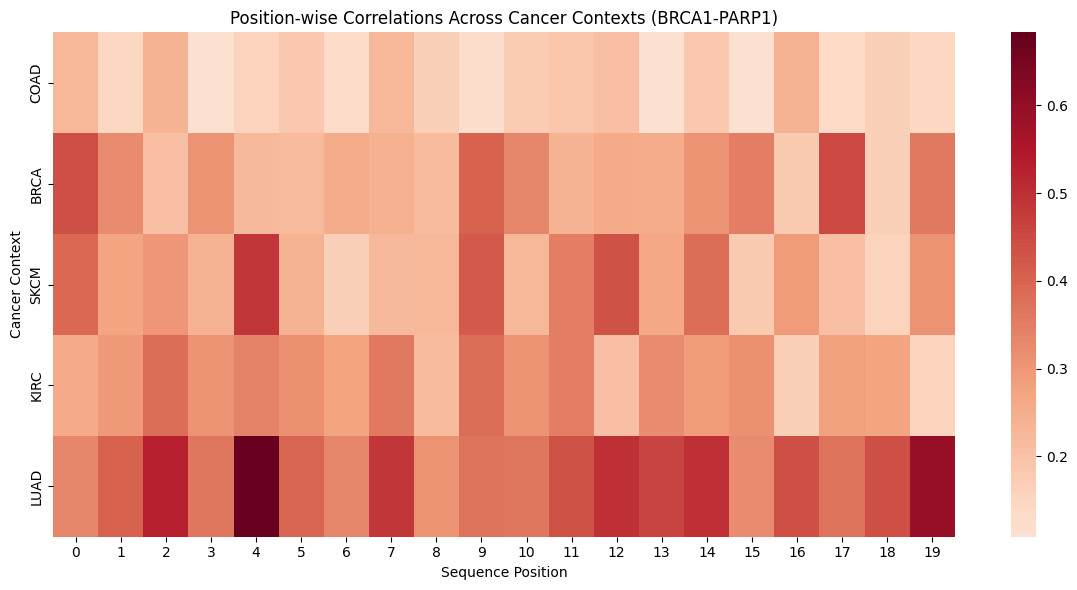

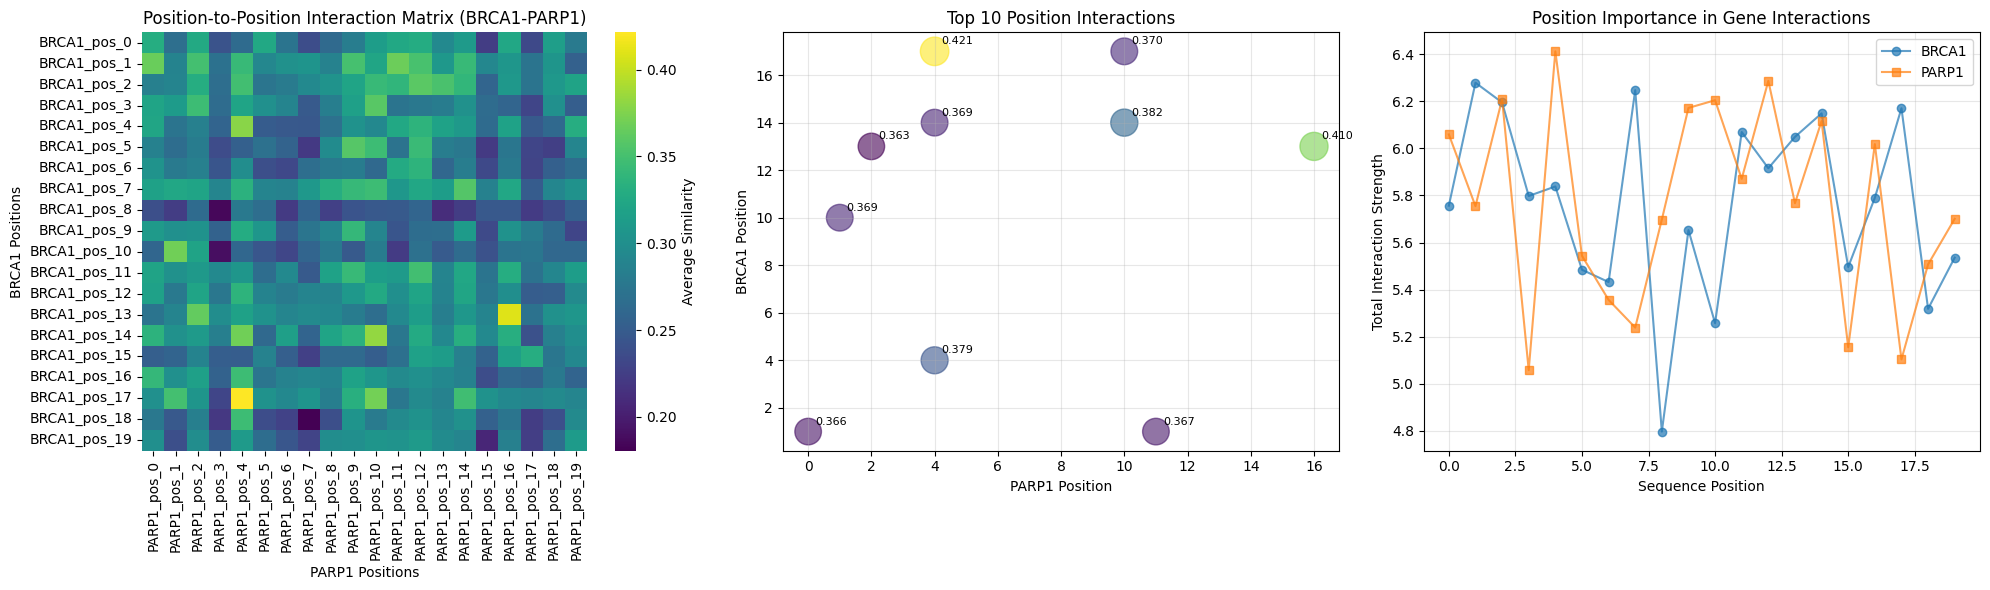

Top 5 position interactions:
1. BRCA1[17] ↔ PARP1[4]: 0.4215
2. BRCA1[13] ↔ PARP1[16]: 0.4099
3. BRCA1[14] ↔ PARP1[10]: 0.3824
4. BRCA1[4] ↔ PARP1[4]: 0.3785
5. BRCA1[17] ↔ PARP1[10]: 0.3698


In [27]:
import seaborn as sns

def analyze_dimensional_correspondence_across_contexts(gene_pair_transformer, gene1_name=None, gene2_name=None):
    """Analyze how dimensional correspondence varies across cancer contexts for any gene pair"""
    
    # Infer gene names if not provided
    if gene1_name is None or gene2_name is None:
        if len(gene_pair_transformer) > 0:
            gene1_name = gene_pair_transformer['primary_gene'].iloc[0]
            gene2_name = gene_pair_transformer['partner_gene'].iloc[0]
        else:
            gene1_name = "Gene1"
            gene2_name = "Gene2"
    
    context_dim_patterns = {}
    context_pos_patterns = {}
    
    for idx, row in gene_pair_transformer.iterrows():
        context = row['context']
        primary_emb = row['primary_embedding']  # Shape: (20, 512)
        partner_emb = row['partner_embedding']   # Shape: (20, 512)
        
        # Position-wise correlations for this context
        pos_corrs = []
        for pos in range(20):
            corr = np.corrcoef(primary_emb[pos], partner_emb[pos])[0, 1]
            pos_corrs.append(corr)
        context_pos_patterns[context] = pos_corrs

    
    # Convert to DataFrames for analysis
    pos_df = pd.DataFrame(context_pos_patterns)
    
    # Plot heatmaps
    fig, ax1 = plt.subplots(1, 1, figsize=(12, 6))
    
    # Position patterns across contexts
    sns.heatmap(pos_df.T, cmap='RdBu_r', center=0, ax=ax1, 
                xticklabels=range(20), yticklabels=pos_df.columns)
    ax1.set_title(f'Position-wise Correlations Across Cancer Contexts ({gene1_name}-{gene2_name})')
    ax1.set_xlabel('Sequence Position')
    ax1.set_ylabel('Cancer Context')
    
    plt.tight_layout()
    plt.show()
    
    return pos_df

def analyze_position_interaction_network(gene_pair_transformer, gene1_name=None, gene2_name=None):
    """Analyze how different sequence positions interact between any gene pair"""
    
    # Infer gene names if not provided
    if gene1_name is None or gene2_name is None:
        if len(gene_pair_transformer) > 0:
            gene1_name = gene_pair_transformer['primary_gene'].iloc[0]
            gene2_name = gene_pair_transformer['partner_gene'].iloc[0]
        else:
            gene1_name = "Gene1"
            gene2_name = "Gene2"
    
    position_interactions = np.zeros((20, 20))  
    
    for idx, row in gene_pair_transformer.iterrows():
        primary_emb = row['primary_embedding']  # (20, 512)
        partner_emb = row['partner_embedding']   # (20, 512)
        
        for i in range(20):  # Primary gene positions
            for j in range(20):  # Partner gene positions
                sim = np.dot(primary_emb[i], partner_emb[j]) / (
                    np.linalg.norm(primary_emb[i]) * np.linalg.norm(partner_emb[j])
                )
                position_interactions[i, j] += sim
    
    # Average across contexts
    position_interactions /= len(gene_pair_transformer)
    
    # Visualize the interaction network
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
    
    # Heatmap of position interactions
    sns.heatmap(position_interactions, 
                xticklabels=[f'{gene2_name}_pos_{i}' for i in range(20)],
                yticklabels=[f'{gene1_name}_pos_{i}' for i in range(20)],
                cmap='viridis', ax=ax1, cbar_kws={'label': 'Average Similarity'})
    ax1.set_title(f'Position-to-Position Interaction Matrix ({gene1_name}-{gene2_name})')
    ax1.set_xlabel(f'{gene2_name} Positions')
    ax1.set_ylabel(f'{gene1_name} Positions')
    
    # Find strongest interactions
    top_interactions = []
    for i in range(20):
        for j in range(20):
            top_interactions.append((i, j, position_interactions[i, j]))
    
    top_interactions.sort(key=lambda x: x[2], reverse=True)
    
    # Plot top interactions
    top_10 = top_interactions[:10]
    gene1_pos = [x[0] for x in top_10]
    gene2_pos = [x[1] for x in top_10]
    strengths = [x[2] for x in top_10]
    
    ax2.scatter(gene2_pos, gene1_pos, s=[s*1000 for s in strengths], 
               alpha=0.6, c=strengths, cmap='viridis')
    ax2.set_xlabel(f'{gene2_name} Position')
    ax2.set_ylabel(f'{gene1_name} Position')
    ax2.set_title('Top 10 Position Interactions')
    ax2.grid(True, alpha=0.3)
    
    # Add interaction strength labels
    for i, (gp1, gp2, strength) in enumerate(top_10):
        ax2.annotate(f'{strength:.3f}', (gp2, gp1), 
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    # Position importance (sum of interactions)
    gene1_importance = np.sum(position_interactions, axis=1)
    gene2_importance = np.sum(position_interactions, axis=0)
    
    ax3.plot(range(20), gene1_importance, 'o-', label=gene1_name, alpha=0.7)
    ax3.plot(range(20), gene2_importance, 's-', label=gene2_name, alpha=0.7)
    ax3.set_xlabel('Sequence Position')
    ax3.set_ylabel('Total Interaction Strength')
    ax3.set_title('Position Importance in Gene Interactions')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return position_interactions, top_interactions

# Updated usage example with automatic gene name detection
pos_patterns_df = analyze_dimensional_correspondence_across_contexts(brca1_parp1_transformer)

position_network, top_position_interactions = analyze_position_interaction_network(brca1_parp1_transformer)

print("Top 5 position interactions:")
for i, (gene1_pos, gene2_pos, strength) in enumerate(top_position_interactions[:5]):
    gene1_name = brca1_parp1_transformer['primary_gene'].iloc[0] if len(brca1_parp1_transformer) > 0 else "Gene1"
    gene2_name = brca1_parp1_transformer['partner_gene'].iloc[0] if len(brca1_parp1_transformer) > 0 else "Gene2"
    print(f"{i+1}. {gene1_name}[{gene1_pos}] ↔ {gene2_name}[{gene2_pos}]: {strength:.4f}")

In [28]:
def analyze_gene_pair_features(gene1, gene2, context=None, embeddings=cross_emb_kg, 
                             pred_df=gene_preds, top_n=10, save_results=False):
    """
    Analyze important features for a gene pair using pre-trained XGBoost classifier.
    Avoids leakage by using saved per-fold scalers.

    Fixes: split primary/partner by feature name prefix to match model training columns,
    not by local split_point which may differ if USE_GF != embeddings source.
    """
    # Extract embeddings for the gene pair
    print(f"Analyzing {gene1}-{gene2}" + (f" in {context}" if context else " across all contexts"))

    result_df = get_embedding_for_gene_pair(
        embeddings=embeddings,
        gene1=gene1, gene2=gene2, cancer=context,
        pred_df=pred_df
    )

    if result_df.empty:
        print(f"No data found for {gene1}-{gene2}" + (f" in {context}" if context else ""))
        return None, None, None

    # Prepare embeddings for XGBoost (pair-level, local view)
    primary_emb_df = pd.DataFrame(result_df['primary_embedding'].tolist())
    primary_emb_df.columns = [f'primary_emb_{i}' for i in range(primary_emb_df.shape[1])]

    partner_emb_df = pd.DataFrame(result_df['partner_embedding'].tolist())
    partner_emb_df.columns = [f'partner_emb_{i}' for i in range(partner_emb_df.shape[1])]

    combined_emb_df = pd.concat([primary_emb_df, partner_emb_df], axis=1)

    # Determine training feature names (global, model view)
    if USE_GF:
        if 'geneformer_emb_total' in globals():
            training_feature_names = list(geneformer_emb_total.columns)
        else:
            # Fallback: use combined as-is
            training_feature_names = list(combined_emb_df.columns)
    else:
        if 'result_kg_emb_total' in globals():
            training_feature_names = list(result_kg_emb_total.columns)
        else:
            training_feature_names = list(combined_emb_df.columns)

    # Align columns to training order if available
    combined_aligned = combined_emb_df.reindex(columns=training_feature_names, fill_value=0)

    # Load pre-trained XGBoost models and get feature importances
    base_dir = 'models/with_KG_attention/XGB_clf_without_score' if not USE_GF else 'models/geneformer_res/XGB_clf_without_score'
    all_importances = []
    for fold in range(1, 6):
        model_path = os.path.join(base_dir, f'model_fold_{fold}.json')
        scaler_path = os.path.join(base_dir, f'scaler_fold_{fold}.pkl')

        X_fold = combined_aligned.values
        if os.path.exists(scaler_path):
            try:
                scaler = joblib.load(scaler_path)
                X_fold = scaler.transform(X_fold)
            except Exception:
                # Proceed without scaling if scaler incompatible
                X_fold = combined_aligned.values

        imp, _ = run_xgb_load_clf(X_fold, model_path=model_path, use_shap=False)
        all_importances.append(imp)

    # Average importances across folds (order matches training_feature_names)
    importances = np.mean(all_importances, axis=0)

    # Build importance table with names and split by prefix for robustness
    imp_table = pd.DataFrame({
        'feature': training_feature_names,
        'importance': importances
    })

    top_primary = (
        imp_table[imp_table['feature'].str.startswith('primary_emb_')]
        .sort_values('importance', ascending=False)
        .head(top_n)
    )
    top_partner = (
        imp_table[imp_table['feature'].str.startswith('partner_emb_')]
        .sort_values('importance', ascending=False)
        .head(top_n)
    )

    # Map feature names to local column indices for selection
    def to_indices(df_cols, features):
        idxs = []
        for f in features:
            try:
                # Expect format like 'primary_emb_1234' or 'partner_emb_5678'
                base, _, idx_str = f.partition('emb_')
                i = int(idx_str)
                if i < len(df_cols):
                    idxs.append(i)
            except Exception:
                continue
        return idxs

    primary_idxs = to_indices(primary_emb_df.columns, list(top_primary['feature']))
    partner_idxs = to_indices(partner_emb_df.columns, list(top_partner['feature']))

    # Create important features dataframes (keep cancer and score)
    primary_important_features = pd.concat([
        primary_emb_df.iloc[:, primary_idxs] if primary_idxs else pd.DataFrame(index=primary_emb_df.index),
        pd.Series(result_df['context'].values, name='cancer'),
        pd.Series(result_df['SLscore'].values, name='score')
    ], axis=1)

    partner_important_features = pd.concat([
        partner_emb_df.iloc[:, partner_idxs] if partner_idxs else pd.DataFrame(index=partner_emb_df.index),
        pd.Series(result_df['context'].values, name='cancer'),
        pd.Series(result_df['SLscore'].values, name='score')
    ], axis=1)

    # Save results if requested
    if save_results:
        save_dir = f'embedding_saved/cross-emb-important/{gene1}-{gene2}' if not USE_GF else f'embedding_saved/geneformer_important/{gene1}-{gene2}'
        if context:
            save_dir += f'_{context}'
        os.makedirs(save_dir, exist_ok=True)

        primary_important_features.to_csv(f'{save_dir}/primary_important_features.csv', index=False)
        partner_important_features.to_csv(f'{save_dir}/partner_important_features.csv', index=False)
        np.save(f'{save_dir}/feature_importances.npy', importances)

    return primary_important_features, partner_important_features, importances

gene_a = 'BRCA1'
gene_b = 'PARP1'
USE_GF = True
primary_features, partner_features, importances = analyze_gene_pair_features(
   gene_a, gene_b, context=None, save_results=True, top_n=20
)
USE_GF = False
primary_features, partner_features, importances = analyze_gene_pair_features(
    gene_a, gene_b, context=None, save_results=True, top_n=20
)

Analyzing BRCA1-PARP1 across all contexts
Found 5 matching instances for BRCA1-PARP1
Analyzing BRCA1-PARP1 across all contexts
Found 5 matching instances for BRCA1-PARP1


In [29]:
# Apply background gradient only to numerical columns (exclude 'cancer' and 'score')
numerical_cols = [col for col in primary_features.columns if col not in ['cancer', 'score']]
primary_features.style.background_gradient(cmap='plasma', subset=numerical_cols, axis=None)

,primary_emb_18,primary_emb_244,primary_emb_120,primary_emb_411,primary_emb_247,primary_emb_346,primary_emb_496,primary_emb_342,primary_emb_485,primary_emb_162,primary_emb_24,primary_emb_335,primary_emb_384,primary_emb_298,primary_emb_226,primary_emb_499,primary_emb_314,primary_emb_386,primary_emb_410,primary_emb_230,cancer,score
0,0.000000,0.125378,0.000000,0.169465,0.000000,0.000000,0.000000,0.000000,0.127481,0.232818,0.000000,0.000000,0.000000,0.114013,0.419458,0.440483,0.131960,0.000000,0.000000,0.379196,COAD,0.002581
1,0.199081,0.060831,0.019641,0.146667,0.168760,0.245474,0.442453,0.594569,0.270028,0.010248,0.167493,0.247750,0.032601,0.097486,0.229342,0.135942,0.000000,0.594913,0.105910,0.013456,BRCA,0.985268
2,0.284275,0.796233,0.002445,0.138399,0.006393,0.189925,0.000000,0.851865,0.022018,0.000000,0.003866,0.012216,0.121806,0.004107,0.195536,0.013495,0.000000,0.108202,0.015343,0.025602,SKCM,0.922286
3,0.007382,0.080395,0.240916,0.394819,0.170108,0.048441,0.000000,0.041042,0.106140,0.237662,0.048656,0.001422,0.025181,0.827129,0.052884,0.000000,0.031804,0.753517,0.197911,0.000000,KIRC,0.295419
4,0.490461,0.020806,0.000000,0.267267,0.607598,0.572830,0.095487,0.132800,0.004647,0.076019,0.011780,0.000000,0.000000,0.113289,0.322294,0.000000,0.003793,0.597165,0.423087,0.212659,LUAD,0.008002


In [30]:
primary_features.shape

(5, 22)

In [31]:
# Apply background gradient only to numerical columns (exclude 'cancer' and 'score')
numerical_cols = [col for col in partner_features.columns if col not in ['cancer', 'score']]
partner_features.style.background_gradient(cmap='plasma', subset=numerical_cols, axis=None)

,partner_emb_230,partner_emb_150,partner_emb_384,partner_emb_325,partner_emb_401,partner_emb_346,partner_emb_299,partner_emb_12,partner_emb_334,partner_emb_470,partner_emb_286,partner_emb_192,partner_emb_443,partner_emb_316,partner_emb_493,partner_emb_298,partner_emb_30,partner_emb_232,partner_emb_78,partner_emb_388,cancer,score
0,0.268694,0.000000,0.000000,0.214533,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.435573,0.651520,0.296350,0.000000,0.000000,0.196386,0.220353,0.142327,0.363141,0.118319,COAD,0.002581
1,0.006746,0.015550,0.023856,0.000000,0.000000,0.184222,0.130390,0.201995,0.005506,0.051189,0.110133,0.045606,0.035512,0.678906,0.027874,0.015267,0.000000,0.163661,0.002206,0.004569,BRCA,0.985268
2,0.000000,0.144650,0.108867,0.089609,0.017927,0.178533,0.023465,0.000000,0.104359,0.226821,0.349875,0.000058,0.506463,0.503358,0.002361,0.000000,0.000000,0.869315,0.916776,0.005100,SKCM,0.922286
3,0.000000,0.005122,0.063190,0.000000,0.084192,0.001780,0.123706,0.000000,0.168988,0.000000,0.004959,0.000000,0.000000,0.288175,0.016755,0.385434,0.013943,0.011190,0.000000,0.000000,KIRC,0.295419
4,0.021818,0.107116,0.000000,0.000000,0.165249,0.525342,0.304043,0.492402,0.296299,0.000000,0.000000,0.000000,0.000000,0.000864,0.000000,0.000000,0.185400,0.002931,0.002339,0.000000,LUAD,0.008002


In [32]:
IDH1_PATH = '/home/jienihu/sc/SLformer/experiment/inference/IDH1_PRKDC_single/'
idh1_res = os.listdir(IDH1_PATH)
idh1_scoring_matrix = np.zeros((len(idh1_res), 8)) # 8 cancers
for idx in range(len(idh1_res)):
    df = pd.read_csv(IDH1_PATH + idh1_res[idx])['avg_score']
    idh1_scoring_matrix[idx] = df.values
idh1_glioma = idh1_scoring_matrix[:, -1]


IDH1_EMB_PATH = '/home/jienihu/sc/SLformer/experiment/emb/IDH1_PRKDC_emb'
BEST_FOLD = 3
idh1_embs = pd.DataFrame()
scoring_df = pd.read_csv(IDH1_PATH + idh1_res[np.argmax(idh1_glioma)])
score = scoring_df[f'score_{BEST_FOLD}']


contexts_avail = os.listdir(IDH1_EMB_PATH)
for context in contexts_avail:
    with_context_path = IDH1_EMB_PATH + f'/{context}'
    emb_file = os.listdir(with_context_path)[2 * np.argmax(idh1_glioma)]
    emb = pkl.load(open(with_context_path + f'/{emb_file}', 'rb'))
    idh1_emb, prkdc_emb = emb[BEST_FOLD-1][0], emb[BEST_FOLD-1][1]
    pair_emb = np.concatenate([idh1_emb, prkdc_emb], axis=0)
    idh1_embs = pd.concat([idh1_embs, pd.DataFrame(pair_emb).T], ignore_index=True)
    
idh1_embs['context'] = contexts_avail
idh1_embs['SLscore'] = score
idh1_embs.columns = [f'primary_emb_{i}' for i in range(idh1_emb.shape[0])] + [f'partner_emb_{i}' for i in range(prkdc_emb.shape[0])] + ['context', 'SLscore']
idh1_embs

,primary_emb_0,primary_emb_1,primary_emb_2,primary_emb_3,primary_emb_4,primary_emb_5,primary_emb_6,primary_emb_7,primary_emb_8,primary_emb_9,...,partner_emb_504,partner_emb_505,partner_emb_506,partner_emb_507,partner_emb_508,partner_emb_509,partner_emb_510,partner_emb_511,context,SLscore
0,0.165571,0.000000,0.097131,0.152494,0.090950,0.096055,0.161412,0.205624,0.089460,0.098780,...,0.057604,0.012493,0.251751,0.384084,0.000000,0.000000,0.103857,0.347548,COAD,0.012469
1,0.025391,0.000000,0.000000,0.020430,0.078672,0.198429,0.412788,0.314775,0.030255,0.000092,...,0.281317,0.003405,0.178923,0.277670,0.049380,0.118358,0.000000,0.384764,LAML,0.084339
2,0.094682,0.013012,0.284993,0.004009,0.077009,0.076318,0.352992,0.038492,0.380259,0.059880,...,0.052812,0.000000,0.393915,0.259869,0.102362,0.123124,0.005940,0.775608,OV,0.268113
3,0.000000,0.000000,0.149566,0.245552,0.029750,0.133357,0.089524,0.128748,0.026488,0.244730,...,0.198616,0.001938,0.365141,0.473631,0.454249,0.004700,0.091806,0.232266,BRCA,0.435550
4,0.191499,0.003051,0.072826,0.080107,0.210498,0.242653,0.283781,0.081931,0.128906,0.009789,...,0.151785,0.006049,0.341714,0.067987,0.007269,0.150766,0.007905,0.631405,CESC,0.002941
5,0.026961,0.000000,0.000000,0.002221,0.001730,0.041531,0.074549,0.118929,0.117865,0.503274,...,0.222365,0.000000,0.254017,0.011614,0.189765,0.226391,0.003208,0.043716,SKCM,0.020995
6,0.055962,0.000000,0.067023,0.068055,0.067863,0.220504,0.083298,0.086192,0.022402,0.202265,...,0.235961,0.004871,0.263633,0.023978,0.198554,0.004168,0.000272,0.258095,LUAD,0.417944
7,0.059640,0.000000,0.226064,0.043419,0.002492,0.277073,0.197727,0.111201,0.079738,0.129580,...,0.083635,0.000000,0.263663,0.368031,0.303156,0.009088,0.002110,0.005268,Glioma,0.903764


In [41]:
importances_df_sort = importances_df.sort_values('mean', ascending=False).index.to_list()
primary_importances, partner_importances = [], []
for i in range(len(importances_df)):
    if importances_df_sort[i].startswith('primary_emb_'):
        primary_importances.append(importances_df_sort[i])
    else:
        partner_importances.append(importances_df_sort[i])
primary_importances_10, partner_importances_10 = primary_importances[:20], partner_importances[:20]

idh1_primary = pd.DataFrame()
for col in primary_importances_10:
    idh1_primary = pd.concat([idh1_primary, idh1_embs[col]], axis=1)
idh1_primary['cancer'] = idh1_embs['context']
idh1_primary['score'] = idh1_embs['SLscore']
idh1_primary.to_csv('embedding_saved/crossemb_important/IDH1-PRKDC/primary_important_features.csv', index=False)

idh1_partner = pd.DataFrame()
for col in partner_importances_10:
    idh1_partner = pd.concat([idh1_partner, idh1_embs[col]], axis=1)
idh1_partner['cancer'] = idh1_embs['context']
idh1_partner['score'] = idh1_embs['SLscore']
idh1_partner.to_csv('embedding_saved/crossemb_important/IDH1-PRKDC/partner_important_features.csv', index=False)

In [ ]:
# Get the names of the top 10 primary and partner features
top_primary = primary_importances[:20]
top_partner = partner_importances[:20]

# Combine them into a single list of important features
important_features = top_primary + top_partner

# Select columns by name from the original DataFrame (not the NumPy array)
X_df = geneformer_emb_total if USE_GF else result_kg_emb_total
valid_features = [f for f in important_features if f in X_df.columns]
missing = sorted(set(important_features) - set(valid_features))
if missing:
    print(f"[warn] Skipping {len(missing)} missing features not found in X columns: {missing}")
assert len(valid_features) > 0, "No valid important features found in the feature matrix columns."
X_important = X_df[valid_features]

# Encode the target variable
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_arr_train_imp, X_arr_test_imp, y_train_imp, y_test_imp = train_test_split(X_important, y_encoded, test_size=0.2, random_state=42)
# scores, feature_importances, top_model = run_xgb_classification(
#     X_arr_train_imp.values, y_train_imp, use_gf=USE_GF, metric='auc', base_dir='XGB_clf_with_top_features'
# )


# # 5-fold CV with a fixed-parameter SVM (no grid search)
# from sklearn.svm import SVC
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import StratifiedKFold
# from sklearn.metrics import f1_score

# svm_fixed = make_pipeline(
#     StandardScaler(),
#     SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced', random_state=42)
#  )

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# fold = 1
# for train_idx, test_idx in skf.split(X_important, y_encoded):
#     X_tr, X_te = X_important.iloc[train_idx].values, X_important.iloc[test_idx].values
#     y_tr, y_te = y_encoded[train_idx], y_encoded[test_idx]
#     svm_fixed.fit(X_tr, y_tr)
#     y_pred = svm_fixed.predict(X_te)
#     f1 = f1_score(y_te, y_pred, average='macro')
#     print(f"Fold {fold} F1 (macro): {f1:.4f}")
#     fold += 1

for i in range(1, 6):
    model = xgb.XGBClassifier()
    model.load_model(f'XGB_checkpoints/model_fold_{i}.json')
    pred = model.predict(X_arr_test_imp)
    print(f'========== Fold {i} ==========')
    print('F1-macro: ' + str(f1_score(y_test_imp, pred, average='macro')))
    print('F1-micro: ' + str(f1_score(y_test_imp, pred, average='micro')))
    print('F1-weighted: ' + str(f1_score(y_test_imp, pred, average='weighted')))

========== Fold 1 ==========
F1-macro: 0.7477059886850809
F1-micro: 0.8984135107471852
F1-weighted: 0.8931825174989645
========== Fold 2 ==========
F1-macro: 0.7293847339830979
F1-micro: 0.8959399522347322
F1-weighted: 0.8902642365355593
========== Fold 3 ==========
F1-macro: 0.761052123657254
F1-micro: 0.89798703514159
F1-weighted: 0.8926370528516159
========== Fold 4 ==========
F1-macro: 0.7323418107476097
F1-micro: 0.8972193790515183
F1-weighted: 0.8915650956542227
========== Fold 5 ==========
F1-macro: 0.753616021878712
F1-micro: 0.8990105765950188
F1-weighted: 0.8938180196071959


In [35]:
geneformer_emb_origin = common_data['geneformer_emb_map']
gene1 = 'IDH1'
gene2 = 'PRKDC'
combined_emb_df = pd.DataFrame()
for cancer in cancer_list:
    cancer_idx = common_data['cancer2id_map'].get(cancer, None)
    g1_idx = gene2id_map[gene1]
    g2_idx = gene2id_map[gene2]
    emb1 = geneformer_emb[cancer_idx][g1_idx]
    emb2 = geneformer_emb[cancer_idx][g2_idx]
    if emb1 is not None and emb2 is not None:
        primary_emb_df = pd.DataFrame(emb1.tolist()).transpose()
        primary_emb_df.columns = [f'primary_emb_{i}' for i in range(256)]
        partner_emb_df = pd.DataFrame(emb2.tolist()).transpose()
        partner_emb_df.columns = [f'partner_emb_{i}' for i in range(256)]
        total_emb_df = pd.concat([primary_emb_df, partner_emb_df], axis=1)
        combined_emb_df = pd.concat([combined_emb_df, total_emb_df], axis=0)
combined_emb_df['context'] = cancer_list
combined_emb_df

,primary_emb_0,primary_emb_1,primary_emb_2,primary_emb_3,primary_emb_4,primary_emb_5,primary_emb_6,primary_emb_7,primary_emb_8,primary_emb_9,...,partner_emb_247,partner_emb_248,partner_emb_249,partner_emb_250,partner_emb_251,partner_emb_252,partner_emb_253,partner_emb_254,partner_emb_255,context
0,0.218848,-0.294287,0.164635,-0.244107,-0.093075,-0.012260,0.389263,0.045362,0.026430,-0.044672,...,-0.258052,-0.018833,0.169003,0.360839,-0.462385,-0.059581,0.026057,0.028680,-0.197317,KIRC
0,0.159550,-0.161360,0.146697,-0.134883,-0.056215,0.013206,0.381768,0.047567,0.043508,-0.003898,...,-0.239795,-0.030854,0.128469,0.355809,-0.435510,-0.054904,0.012376,0.044674,-0.236817,COAD
0,0.202454,-0.167102,0.158985,-0.170700,-0.063336,-0.001578,0.362023,0.070683,-0.001856,0.024494,...,-0.215197,-0.093137,0.182447,0.336799,-0.389441,-0.064001,0.016044,0.063908,-0.181263,LAML
0,0.181316,-0.228559,0.136067,-0.204862,-0.068083,-0.000895,0.368259,0.046089,0.025614,-0.023460,...,-0.219002,-0.075803,0.151115,0.344040,-0.378087,-0.055735,0.037930,0.013011,-0.248322,OV
0,0.118382,-0.071325,0.154846,-0.113238,-0.068580,0.041242,0.386128,0.047807,0.077426,-0.009421,...,-0.185471,-0.153272,0.132453,0.272442,-0.238190,-0.063763,0.045030,-0.001148,-0.283968,BRCA
0,0.223470,-0.189282,0.159328,-0.207980,-0.039117,0.003225,0.388186,0.047084,0.028658,-0.020873,...,-0.231340,-0.070321,0.150679,0.396260,-0.399840,-0.057532,0.009535,0.038867,-0.265421,CESC
0,-0.006253,0.147067,0.087126,-0.076648,-0.112523,0.049334,0.273443,0.071032,0.123945,0.014414,...,-0.125970,-0.089768,0.139179,0.148069,-0.147171,0.010447,0.128886,0.031070,-0.160373,SKCM
0,0.203930,-0.148048,0.173115,-0.171828,-0.072455,0.014968,0.375168,0.051529,0.001972,0.007361,...,-0.243552,-0.054480,0.197367,0.350934,-0.413627,-0.050791,0.043506,0.040485,-0.227358,LUAD
0,0.175151,-0.181334,0.141914,-0.189062,-0.034823,-0.008741,0.352955,0.059058,0.044846,0.002653,...,-0.243937,-0.078518,0.147193,0.331164,-0.384932,-0.076630,0.041088,0.026925,-0.262306,Glioma


In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.decomposition import PCA
import umap.umap_ as umap
from sklearn.manifold import TSNE, LocallyLinearEmbedding, Isomap, SpectralEmbedding

def plot_feature_importance_histogram(importances, feature_names, top_n=20, title="Top Feature Importances"):
    """Creates a horizontal bar chart (histogram) for the top N feature importances."""
    df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    df = df.sort_values('importance', ascending=False).head(top_n)
    
    # Create a colormap for better visualization
    colors = plt.cm.viridis(np.linspace(0, 1, len(df)))
    
    plt.figure(figsize=(16, max(8, top_n * 0.4)))
    
    # Create horizontal bar chart
    bars = plt.barh(range(len(df)), df['importance'], color=colors, alpha=0.8, edgecolor='white', linewidth=0.5)
    
    # Customize the plot
    plt.yticks(range(len(df)), df['feature'], fontsize=15)
    plt.gca().invert_yaxis()  # Highest importance at top
    plt.xlabel('Importance Score', fontsize=20)
    plt.ylabel('Feature', fontsize=20)
    plt.title(title, fontsize=24)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    
    # Add value labels on bars
    for i, (bar, importance) in enumerate(zip(bars, df['importance'])):
        plt.text(importance + importance * 0.01, bar.get_y() + bar.get_height()/2, 
                f'{importance:.4f}', ha='left', va='center', fontsize=15, alpha=0.8)
    
    plt.tight_layout()
    plt.show()

def plot_shap_summary(X, model, feature_names, class_names):
    """Generates and plots a SHAP summary plot."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    
    palette = plt.get_cmap('plasma', len(class_names))
    
    shap.summary_plot(shap_values, X, feature_names=feature_names, 
                      class_names=class_names, plot_type='bar',
                      show=False, color=palette)
    plt.title("SHAP Summary Plot (Mean absolute SHAP value for each class)")
    plt.tight_layout()
    plt.show()
    
    # Beeswarm plot for a specific class (e.g., Glioma)
    try:
        glioma_index = list(class_names).index('Glioma')
        print("\nPlotting SHAP beeswarm plot for Glioma...")
        shap.summary_plot(shap_values[glioma_index], X, feature_names=feature_names,
                          show=False, cmap=plt.get_cmap('coolwarm'))
        plt.title("SHAP Feature Importance for Glioma")
        plt.tight_layout()
        plt.show()
    except ValueError:
        print("Glioma not found in class names, skipping beeswarm plot.")

In [37]:
# Additional plotting functions for feature importance analysis

def plot_feature_importance_violin(importances, feature_names, top_n=30, title="Feature Importance Distribution"):
    """Creates a violin plot showing the distribution of feature importances."""
    df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    df = df.sort_values('importance', ascending=False).head(top_n)
    
    plt.figure(figsize=(16, 12))
    
    # Create violin plot
    parts = plt.violinplot([df['importance']], positions=[0], showmeans=True, showmedians=True)
    
    # Customize colors
    for pc in parts['bodies']:
        pc.set_facecolor('blue')
        pc.set_alpha(0.2)
    
    # Add scatter plot overlay with larger dots
    y_positions = np.random.normal(0, 0.04, len(df))
    scatter = plt.scatter(y_positions, df['importance'], 
                         c=plt.cm.plasma(np.linspace(0, 1, len(df))), 
                         alpha=0.8, s=120, edgecolors='white', linewidth=0.8)
    
    # Add feature names as annotations for top features (no rotation)
    for i, (importance, feature) in enumerate(zip(df['importance'].head(10), df['feature'].head(10))):
        plt.annotate(feature, (y_positions[i], importance), 
                    xytext=(15, 5), textcoords='offset points',
                    fontsize=20, alpha=0.8, ha='left', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'))
    
    plt.ylabel('Importance Score', fontsize=20)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize=24)
    plt.xticks([0], ['Features'], fontsize=20)
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_fold_variance_analysis(importances_df, top_n=20, title="Feature Importance Fold Variance Analysis"):
    """
    Plot showing error/variance between each fold and the 5-fold average for top features.
    Shows how consistent feature importance is across different CV folds.
    """
    # Get top N features based on mean importance
    top_features = importances_df.nlargest(top_n, 'mean')
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Plot 1: Individual fold importances vs average for top features
    fold_cols = [col for col in importances_df.columns if col.startswith('fold_')]
    x_pos = np.arange(top_n)
    
    # Colors for each fold
    colors = plt.cm.Set3(np.linspace(0, 1, len(fold_cols)))
    
    # Plot each fold's importances
    for i, fold_col in enumerate(fold_cols):
        ax1.scatter(x_pos, top_features[fold_col], 
                   alpha=0.7, s=80, color=colors[i], label=f'Fold {i+1}', 
                   edgecolors='white', linewidth=0.5)
    
    # Plot the average as a line
    ax1.plot(x_pos, top_features['mean'], 'ko-', linewidth=2, markersize=6, 
             label='5-Fold Average', alpha=0.8)
    
    # Add error bars showing standard deviation
    std_values = top_features[fold_cols].std(axis=1)
    ax1.errorbar(x_pos, top_features['mean'], yerr=std_values, 
                fmt='none', color='black', alpha=0.5, capsize=3)
    
    ax1.set_xlabel('Feature Rank', fontsize=12)
    ax1.set_ylabel('Feature Importance', fontsize=12)
    ax1.set_title(f'Top {top_n} Features: Individual Folds vs Average', fontsize=14, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # Set x-axis labels to feature names (rotated)
    feature_names = [name.replace('primary_emb_', 'P_').replace('partner_emb_', 'Pt_')[:15] 
                    for name in top_features.index]
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
    
    # Plot 2: Error magnitude (absolute deviation from mean) for each feature
    errors_df = top_features[fold_cols].sub(top_features['mean'], axis=0).abs()
    mean_abs_error = errors_df.mean(axis=1)
    
    # Create heatmap of absolute errors
    im = ax2.imshow(errors_df.T, cmap='Reds', aspect='auto', interpolation='nearest')
    
    # Customize heatmap
    ax2.set_xlabel('Feature Rank', fontsize=12)
    ax2.set_ylabel('Cross-Validation Fold', fontsize=12)
    ax2.set_title(f'Absolute Error from 5-Fold Average', fontsize=14, fontweight='bold')
    
    # Set ticks and labels
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'{i+1}' for i in range(top_n)])
    ax2.set_yticks(range(len(fold_cols)))
    ax2.set_yticklabels([f'Fold {i+1}' for i in range(len(fold_cols))])
    
    # Add colorbar
    cbar = plt.colorbar(im, ax=ax2)
    cbar.set_label('Absolute Error', fontsize=10)
    
    # Add text annotations for error values
    for i in range(len(fold_cols)):
        for j in range(top_n):
            text = ax2.text(j, i, f'{errors_df.iloc[j, i]:.3f}', 
                           ha="center", va="center", fontsize=8, color="white" if errors_df.iloc[j, i] > errors_df.values.max()/2 else "black")
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n=== Fold Variance Analysis Summary ===")
    print(f"Average absolute error across all features: {errors_df.values.mean():.4f}")
    print(f"Maximum absolute error: {errors_df.values.max():.4f}")
    print(f"Features with highest variance (top 5):")
    most_variable = mean_abs_error.nlargest(5)
    for feat, error in most_variable.items():
        print(f"  {feat}: {error:.4f} average absolute error")
    
    print(f"\nMost stable features (top 5):")
    most_stable = mean_abs_error.nsmallest(5)
    for feat, error in most_stable.items():
        print(f"  {feat}: {error:.4f} average absolute error")

=== Feature Importance Visualization ===

1. Histogram Visualization:


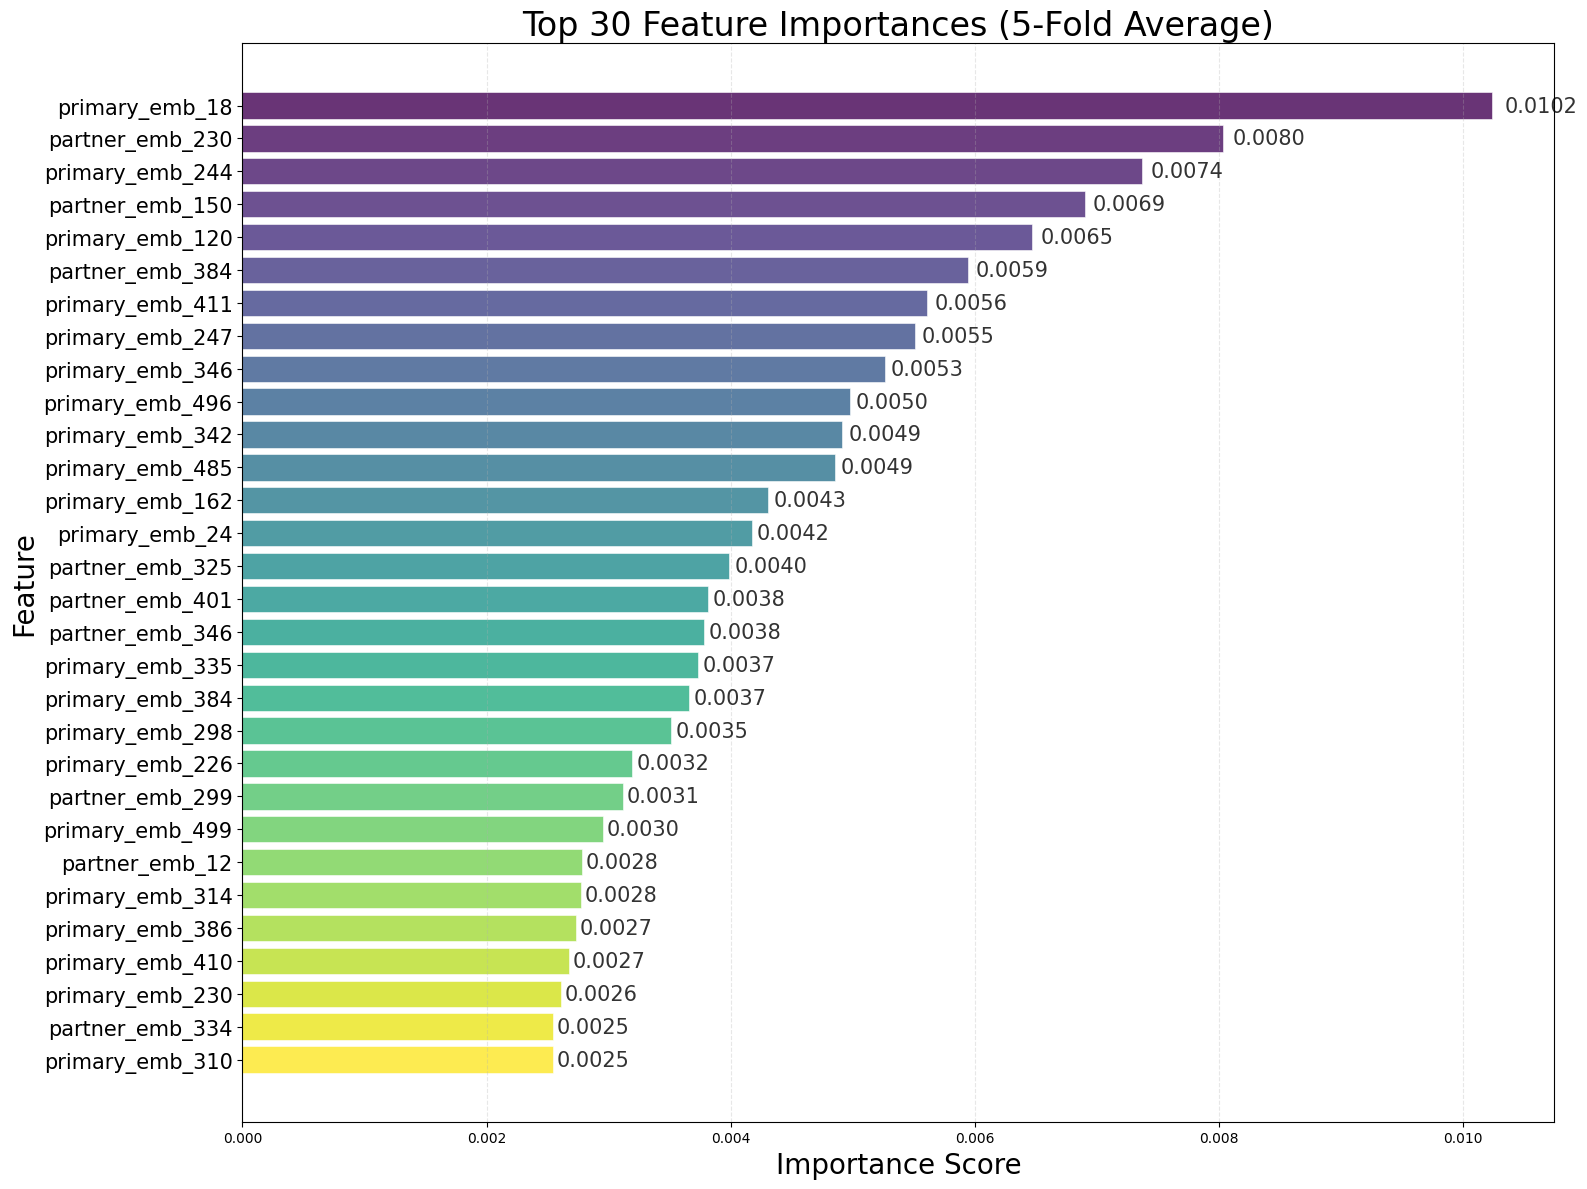


2. Violin Plot Distribution:


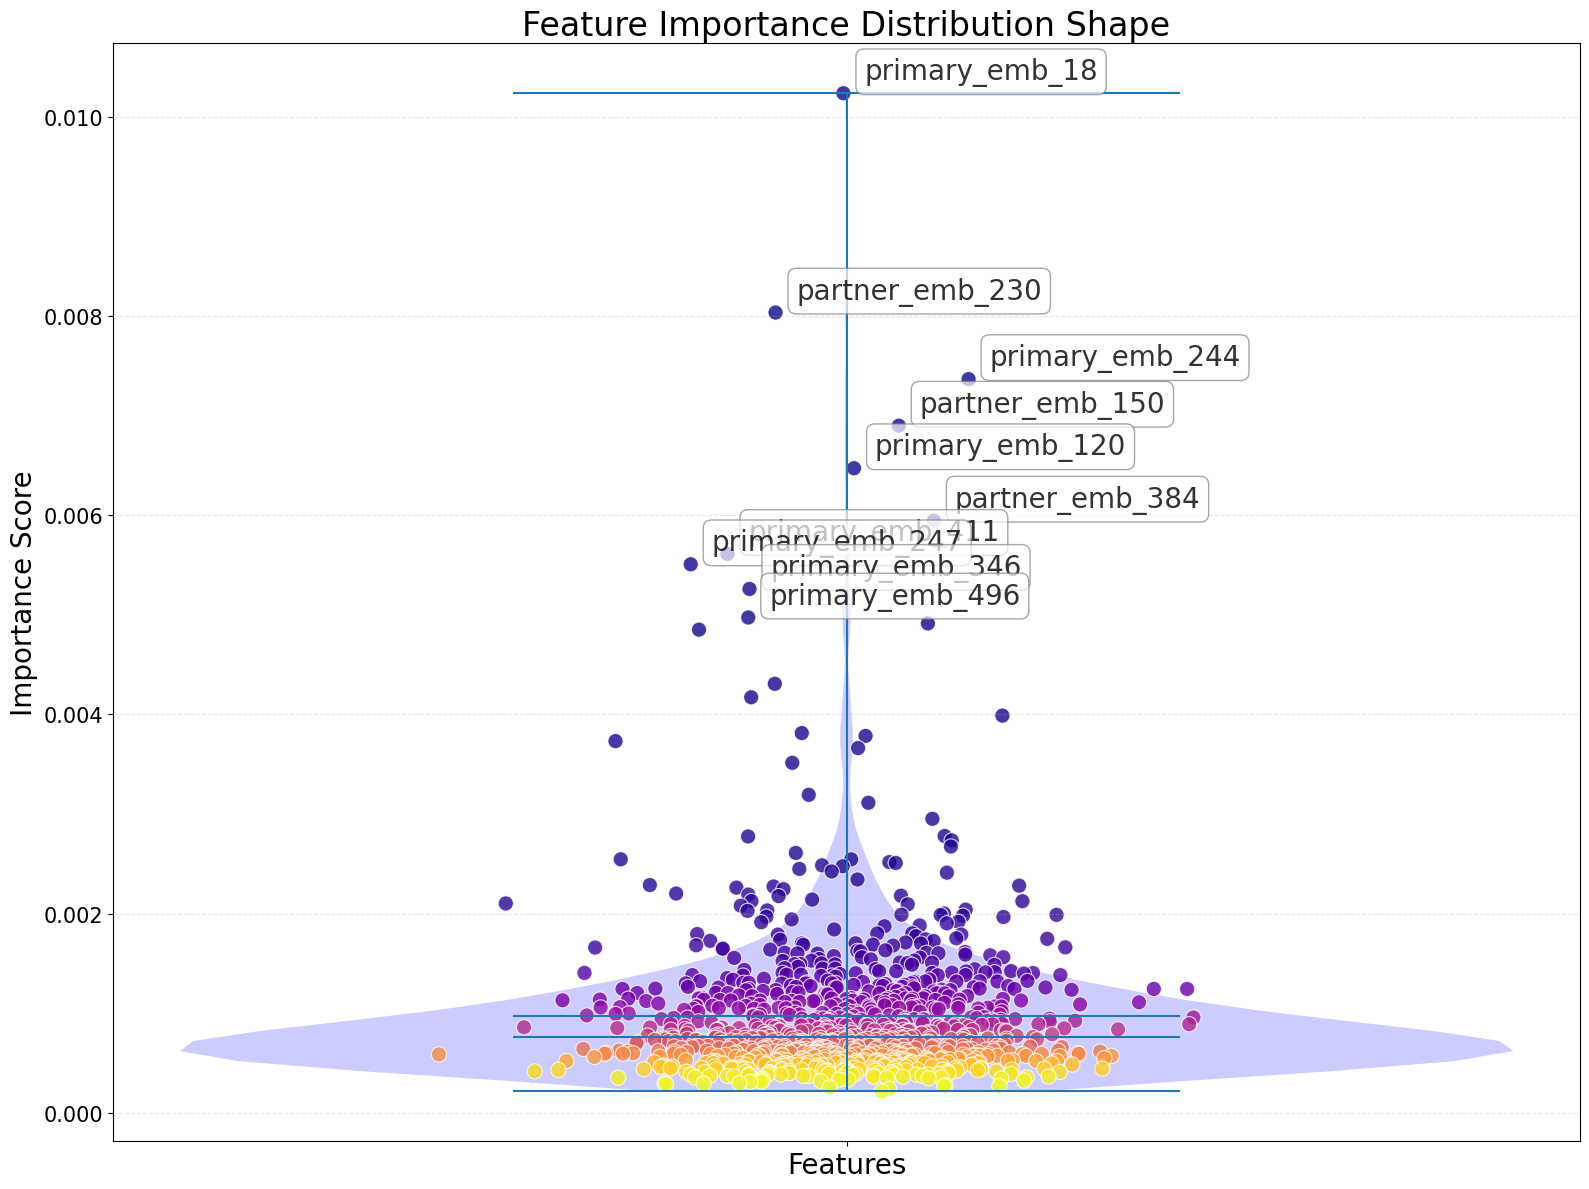


3. Cross-Validation Fold Variance Analysis:


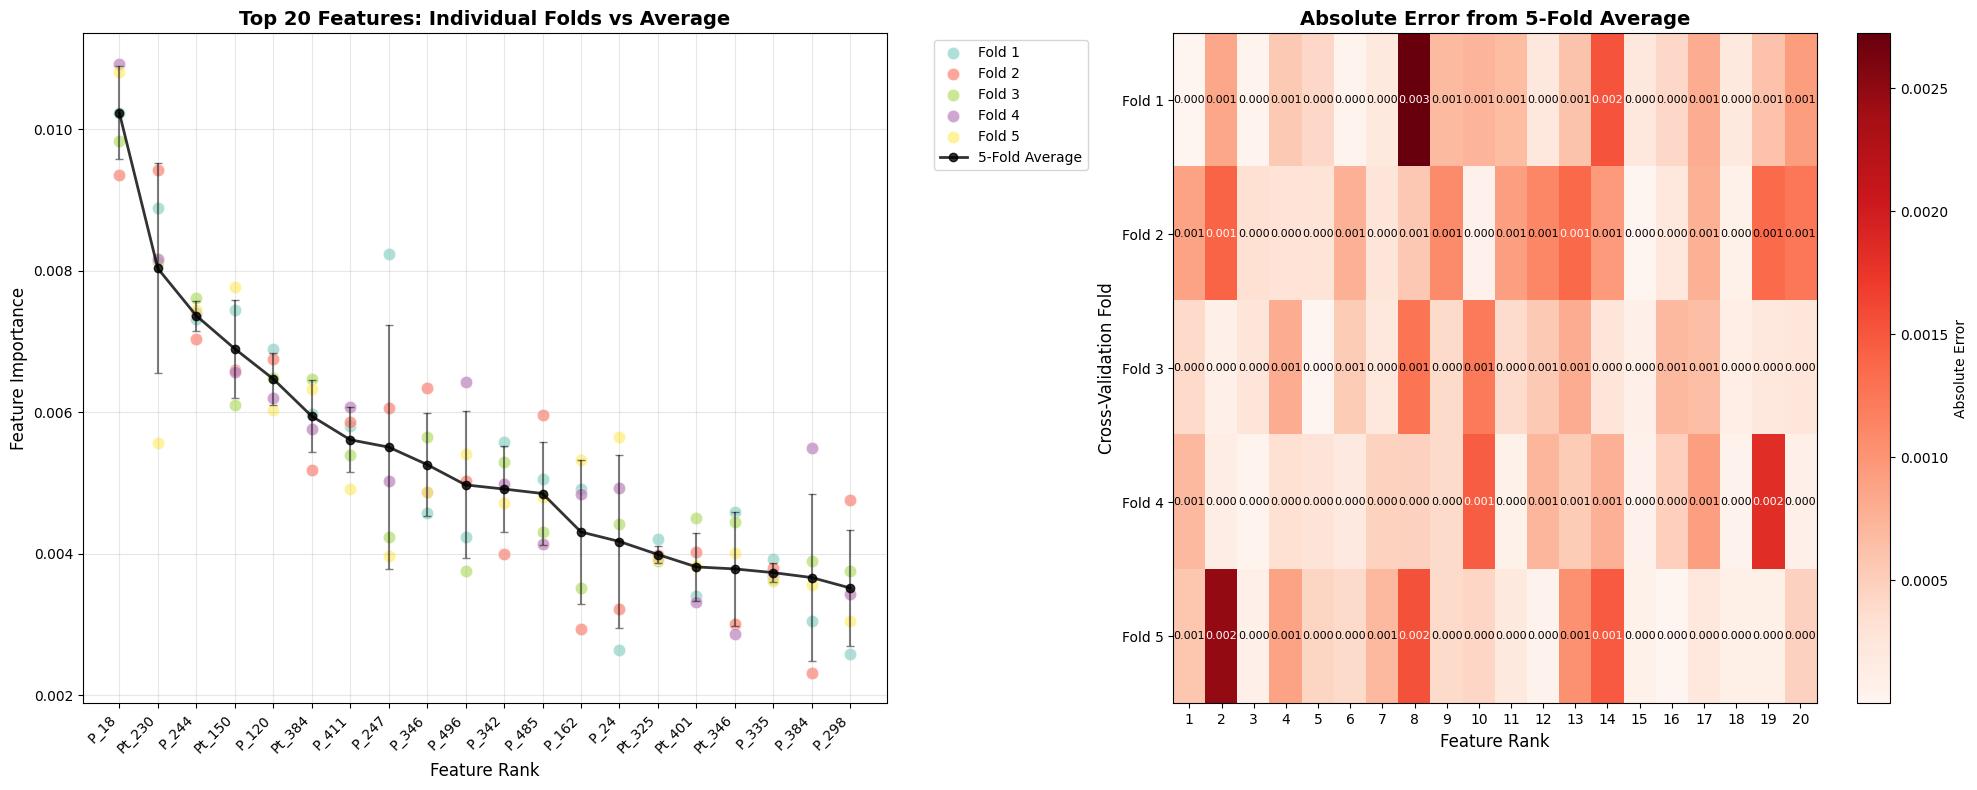


=== Fold Variance Analysis Summary ===
Average absolute error across all features: 0.0006
Maximum absolute error: 0.0027
Features with highest variance (top 5):
  primary_emb_247: 0.0013 average absolute error
  primary_emb_24: 0.0010 average absolute error
  partner_emb_230: 0.0010 average absolute error
  primary_emb_162: 0.0009 average absolute error
  primary_emb_384: 0.0008 average absolute error

Most stable features (top 5):
  partner_emb_325: 0.0001 average absolute error
  primary_emb_335: 0.0001 average absolute error
  primary_emb_244: 0.0001 average absolute error
  primary_emb_120: 0.0003 average absolute error
  primary_emb_411: 0.0004 average absolute error


In [38]:
# Feature importance visualization with histogram, violin plot, and fold variance analysis
print("=== Feature Importance Visualization ===\n")

# Use the 5-fold average importances
avg_importances = importances_df['mean'].values
feature_names = result_kg_emb_total.columns if not USE_GF else geneformer_emb_total.columns
TOP_N = 30

# 1. Histogram visualization
print("1. Histogram Visualization:")
plot_feature_importance_histogram(avg_importances, feature_names, top_n=TOP_N, 
                                 title=f"Top {TOP_N} Feature Importances (5-Fold Average)")

# 2. Violin plot for distribution shape
print("\n2. Violin Plot Distribution:")
plot_feature_importance_violin(avg_importances, feature_names, top_n=len(feature_names),
                              title="Feature Importance Distribution Shape")

# 3. Fold variance analysis
print("\n3. Cross-Validation Fold Variance Analysis:")
plot_fold_variance_analysis(importances_df, top_n=20,
                           title="Feature Importance Consistency Across CV Folds")

In [4]:
def create_gbm_xgb_training_sets():

    with open('/home/guoyu/SLformer_interpretation/data/saved_data/map/gene2id.pkl', 'rb') as f:
        gene2id = pkl.load(f)
    
    total_df = pd.DataFrame()
    for i in range(5):
        path = f'/home/guoyu/SLformer_interpretation/data/saved_data/SL_train_test_data/mix_add_GBM_stratified/train_all_fold_{i + 1}.npy'
        train_data = np.load(path, allow_pickle=True)
        df = pd.DataFrame(train_data, columns=['primary_gene', 'partner_gene', 'label', 'cancer'])
        total_df = pd.concat([total_df, df], ignore_index=True)
    id2gene = {v: k for k, v in gene2id.items()}
    total_df['primary_gene'] = total_df['primary_gene'].map(id2gene)
    total_df['partner_gene'] = total_df['partner_gene'].map(id2gene)
    id2cancer_map = {i:c for i,c in enumerate(cancer_list)}
    total_df['cancer'] = total_df['cancer'].map(id2cancer_map)
    total_df = total_df.drop_duplicates()
    return total_df
total_df = create_gbm_xgb_training_sets()

In [40]:
total_df.shape

(58672, 4)